In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import optuna
from optuna.samplers import TPESampler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             classification_report)
from google.colab import files

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

C_SV     = '#1B9E77'
C_STATIC = '#D95F02'

In [5]:
FEATURE_COLS = [
    'Electrical speed [rad/s]',
    'I_M_a', 'I_M_b', 'I_M_c',
    'I_P_a', 'I_P_b', 'I_P_c',
    'I_B_a', 'I_B_b', 'I_B_c',
    'V_M_a', 'V_M_b', 'V_M_c',
    'V_P_a', 'V_P_b', 'V_P_c',
    'V_B_a', 'V_B_b', 'V_B_c'
]
LABEL_COL = 'Class label'

def optimize_svm(X, y, n_trials=50, name=""):
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    def objective(trial):
        C = trial.suggest_float('C', 1e-1, 1e4, log=True)
        gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
        svc = SVC(C=C, gamma=gamma, kernel='rbf', class_weight='balanced')
        return cross_val_score(svc, X, y, cv=cv, scoring='accuracy', n_jobs=-1).mean()
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    C_opt = study.best_params['C']
    gamma_opt = study.best_params['gamma']
    print(f"  [{name}] Best: C={C_opt:.4f}, gamma={gamma_opt:.6f}, CV={study.best_value:.4f}")
    return C_opt, gamma_opt

In [14]:
uploaded = files.upload()

dfs = []
for fname in sorted(uploaded.keys()):
    df_tmp = pd.read_csv(fname)
    dfs.append(df_tmp)
    print(f"  {fname}: {len(df_tmp)} samples")

df_init = pd.concat(dfs, ignore_index=True)
X_all = df_init[FEATURE_COLS].values
y_all = df_init[LABEL_COL].values

print(f"\nTotal: {len(y_all)} samples")
for c in sorted(np.unique(y_all)):
    print(f"  Class {c:2d} : {np.sum(y_all == c):4d} samples")

Saving data_exp8.csv to data_exp8 (1).csv
Saving data_exp10.csv to data_exp10.csv
  data_exp10.csv: 4500 samples
  data_exp8 (1).csv: 6796 samples

Total: 11296 samples
  Class  1 : 4545 samples
  Class  2 :  446 samples
  Class  3 :  450 samples
  Class  4 :  455 samples
  Class  5 :  450 samples
  Class  6 :  450 samples
  Class  7 :  450 samples
  Class  8 :  450 samples
  Class  9 :  450 samples
  Class 10 :  450 samples
  Class 11 :  450 samples
  Class 12 :  450 samples
  Class 13 :  450 samples
  Class 14 :  450 samples
  Class 15 :  450 samples
  Class 16 :  450 samples


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {len(y_train)} | Test: {len(y_test)}")
print(f"Classes: {sorted(np.unique(y_train))}\n")

C_base, gamma_base = optimize_svm(X_train_sc, y_train, n_trials=50, name="Base")
t0 = time.time()
base_expert = SVC(C=C_base, gamma=gamma_base, kernel='rbf',
                  class_weight='balanced', probability=True, random_state=42)
base_expert.fit(X_train_sc, y_train)
base_time = time.time() - t0

acc_base = accuracy_score(y_test, base_expert.predict(X_test_sc))
f1_base = f1_score(y_test, base_expert.predict(X_test_sc), average='macro')

print(f"\nExpert initial:")
print(f"  Accuracy: {acc_base:.4f} | F1 macro: {f1_base:.4f}")
print(f"  SVs: {len(base_expert.support_)} | Fit time: {base_time:.3f}s")
print(f"  Train samples: {len(y_train)}")

Train: 9036 | Test: 2260
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]



  0%|          | 0/50 [00:00<?, ?it/s]

  [Base] Best: C=9976.7114, gamma=0.386773, CV=0.9552

Expert initial:
  Accuracy: 0.9673 | F1 macro: 0.9664
  SVs: 2492 | Fit time: 22.456s
  Train samples: 9036


In [16]:
#file that contain the new data for refinement
uploaded2 = files.upload()

dfs2 = []
for fname in sorted(uploaded2.keys()):
    df_tmp = pd.read_csv(fname)
    dfs2.append(df_tmp)
    print(f"  {fname}: {len(df_tmp)} samples")

df_new = pd.concat(dfs2, ignore_index=True)
X_new = df_new[FEATURE_COLS].values
y_new = df_new[LABEL_COL].values

X_new_sc = scaler.transform(X_new)

Saving data_exp9.csv to data_exp9 (1).csv
  data_exp9 (1).csv: 5305 samples


In [17]:
#commparison
X_sv = X_train_sc[base_expert.support_]
y_sv = y_train[base_expert.support_]

X_svt = np.vstack([X_sv, X_new_sc])
y_svt = np.hstack([y_sv, y_new])

print("SV Transfer:")

t0_total = time.time()
C_svt, gamma_svt = optimize_svm(X_svt, y_svt, n_trials=50, name="SV Transfer")
svt_optuna_time = time.time() - t0_total

t0 = time.time()
expert_svt = SVC(C=C_svt, gamma=gamma_svt, kernel='rbf',
                 class_weight='balanced', probability=True, random_state=42)
expert_svt.fit(X_svt, y_svt)
svt_fit_time = time.time() - t0
svt_total_time = time.time() - t0_total

acc_svt = accuracy_score(y_test, expert_svt.predict(X_test_sc))
f1_svt = f1_score(y_test, expert_svt.predict(X_test_sc), average='macro')

print(f"  Accuracy: {acc_svt:.4f} | F1: {f1_svt:.4f}")
print(f"  SVs: {len(expert_svt.support_)}")
print(f"  Fit time: {svt_fit_time:.3f}s | Optuna: {svt_optuna_time:.3f}s | Total: {svt_total_time:.3f}s")

#static svm
X_static = np.vstack([X_train_sc, X_new_sc])
y_static = np.hstack([y_train, y_new])

print(f"\nStatic SVM:")

t0_total = time.time()
C_st, gamma_st = optimize_svm(X_static, y_static, n_trials=50, name="Static SVM")
st_optuna_time = time.time() - t0_total

t0 = time.time()
expert_st = SVC(C=C_st, gamma=gamma_st, kernel='rbf',
                class_weight='balanced', probability=True, random_state=42)
expert_st.fit(X_static, y_static)
st_fit_time = time.time() - t0
st_total_time = time.time() - t0_total

acc_st = accuracy_score(y_test, expert_st.predict(X_test_sc))
f1_st = f1_score(y_test, expert_st.predict(X_test_sc), average='macro')

SV Transfer:


  0%|          | 0/50 [00:00<?, ?it/s]

  [SV Transfer] Best: C=9574.7666, gamma=0.093117, CV=0.9143
  Accuracy: 0.9597 | F1: 0.9572
  SVs: 2058
  Fit time: 8.889s | Optuna: 219.914s | Total: 228.802s

Static SVM:


  0%|          | 0/50 [00:00<?, ?it/s]

  [Static SVM] Best: C=5440.4355, gamma=2.632940, CV=0.9612


/tmp/ipykernel_463/2324635741.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


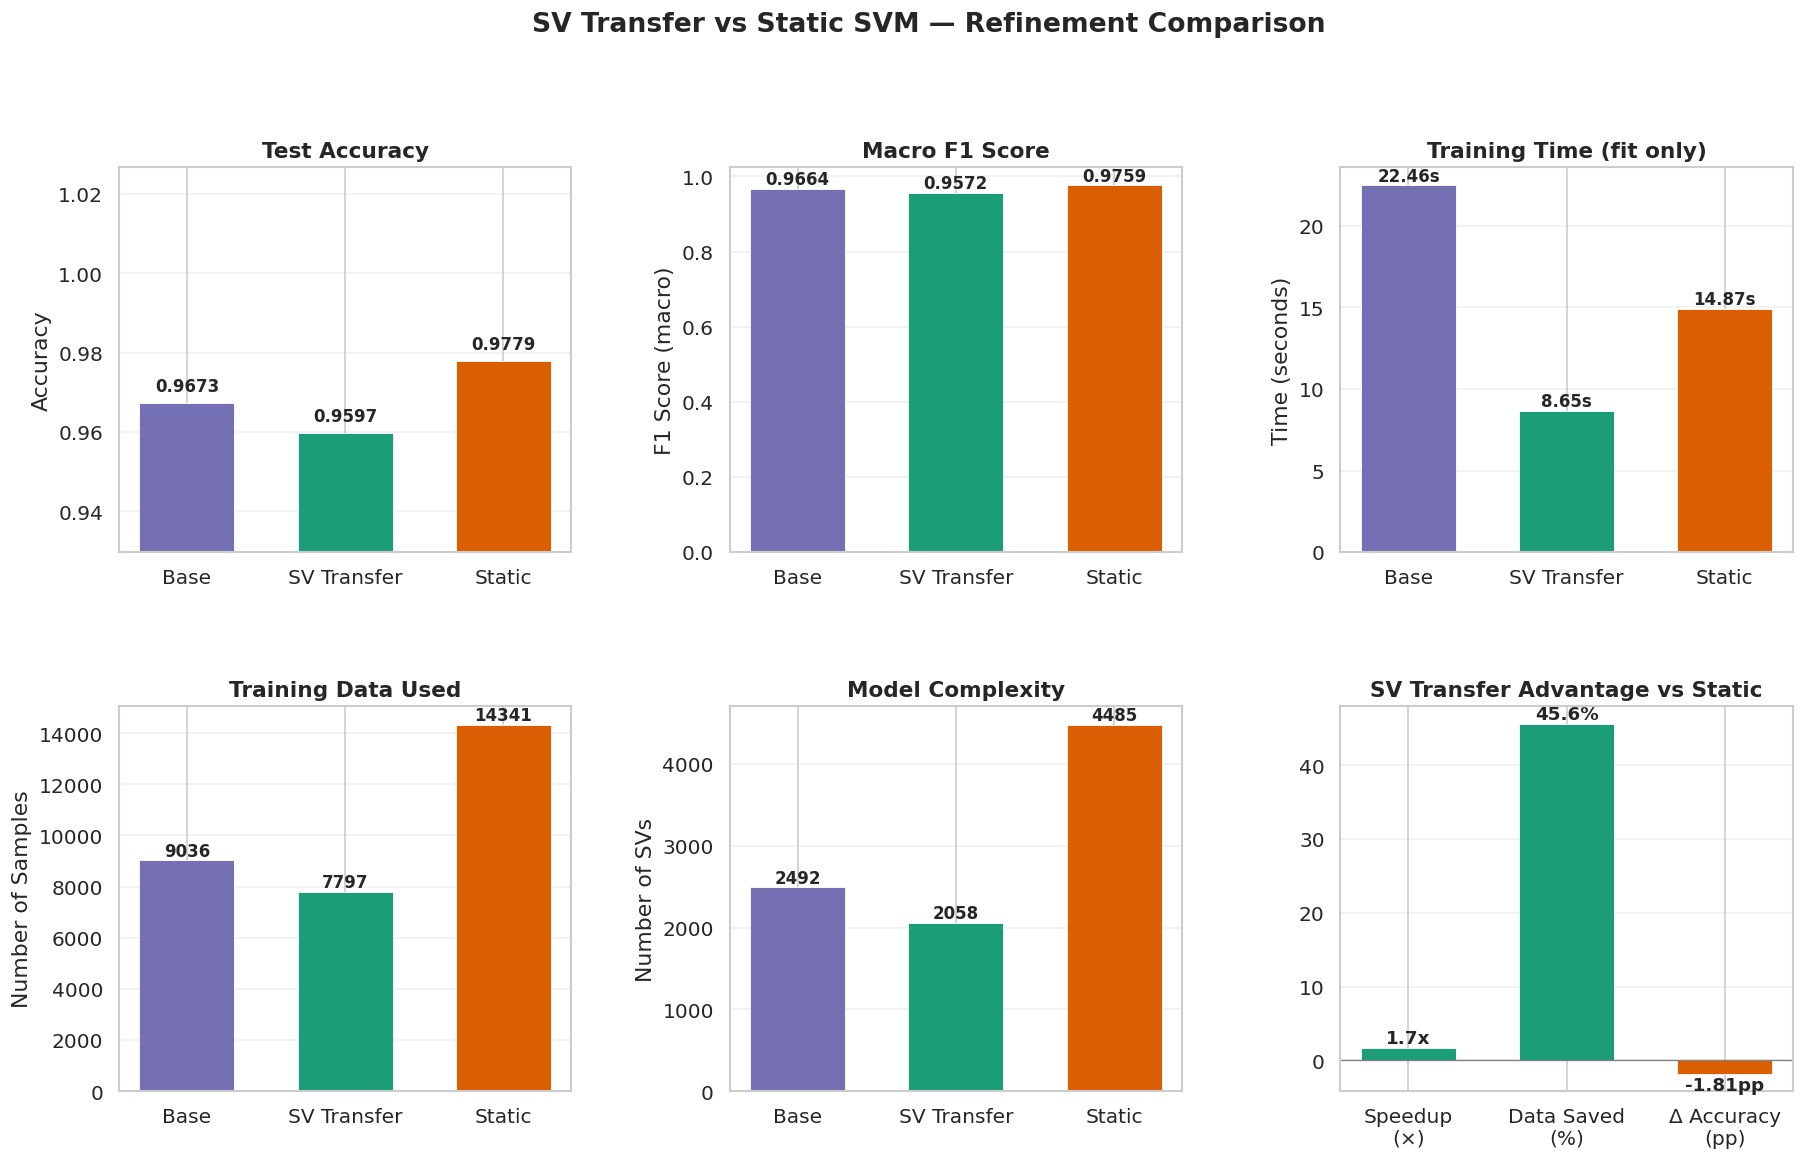

In [18]:
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

methods_short = ['Base', 'SV Transfer', 'Static']
colors3 = ['#7570B3', C_SV, C_STATIC]
x3 = np.arange(3)

# accuracy
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(x3, [acc_base, acc_svt, acc_st], color=colors3,
               edgecolor='white', linewidth=0.5, width=0.6)
for b in bars:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
             f'{b.get_height():.4f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax1.set_xticks(x3)
ax1.set_xticklabels(methods_short)
ax1.set_ylabel('Accuracy')
ax1.set_title('Test Accuracy', fontweight='bold', fontsize=13)
ax1.set_ylim(bottom=max(0, min(acc_base, acc_svt, acc_st) - 0.03))
ax1.grid(True, alpha=0.3, axis='y')

# f1
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(x3, [f1_base, f1_svt, f1_st], color=colors3,
               edgecolor='white', linewidth=0.5, width=0.6)
for b in bars:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
             f'{b.get_height():.4f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax2.set_xticks(x3)
ax2.set_xticklabels(methods_short)
ax2.set_ylabel('F1 Score (macro)')
ax2.set_title('Macro F1 Score', fontweight='bold', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

# time
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(x3, [base_time, svt_time, static_time], color=colors3,
               edgecolor='white', linewidth=0.5, width=0.6)
for b in bars:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
             f'{b.get_height():.2f}s', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax3.set_xticks(x3)
ax3.set_xticklabels(methods_short)
ax3.set_ylabel('Time (seconds)')
ax3.set_title('Training Time (fit only)', fontweight='bold', fontsize=13)
ax3.grid(True, alpha=0.3, axis='y')

# number of data
ax4 = fig.add_subplot(gs[1, 0])
samples = [len(y_train), len(y_svt), len(y_static)]
bars = ax4.bar(x3, samples, color=colors3,
               edgecolor='white', linewidth=0.5, width=0.6)
for b, s in zip(bars, samples):
    ax4.text(b.get_x() + b.get_width()/2, b.get_height() + 10,
             f'{s}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
# Reduction annotation
reduction = (1 - len(y_svt)/len(y_static))*100
ax4.set_xticks(x3)
ax4.set_xticklabels(methods_short)
ax4.set_ylabel('Number of Samples')
ax4.set_title('Training Data Used', fontweight='bold', fontsize=13)
ax4.grid(True, alpha=0.3, axis='y')

# SVs
ax5 = fig.add_subplot(gs[1, 1])
svs = [len(base_expert.support_), len(expert_svt.support_), len(expert_st.support_)]
bars = ax5.bar(x3, svs, color=colors3,
               edgecolor='white', linewidth=0.5, width=0.6)
for b, s in zip(bars, svs):
    ax5.text(b.get_x() + b.get_width()/2, b.get_height() + 5,
             f'{s}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax5.set_xticks(x3)
ax5.set_xticklabels(methods_short)
ax5.set_ylabel('Number of SVs')
ax5.set_title('Model Complexity', fontweight='bold', fontsize=13)
ax5.grid(True, alpha=0.3, axis='y')


ax6 = fig.add_subplot(gs[1, 2])
speedup = static_time / svt_time
data_red = reduction
acc_delta = (acc_svt - acc_st) * 100

bar_labels = ['Speedup\n(×)', 'Data Saved\n(%)', 'Δ Accuracy\n(pp)']
bar_vals = [speedup, data_red, acc_delta]
bar_colors = [C_SV, C_SV, C_SV if acc_delta >= 0 else C_STATIC]

bars = ax6.bar(np.arange(3), bar_vals, color=bar_colors,
               edgecolor='white', linewidth=0.5, width=0.6)
for b, v in zip(bars, bar_vals):
    label = f'{v:.1f}x' if b == bars[0] else f'{v:.1f}%' if b == bars[1] else f'{v:+.2f}pp'
    ax6.text(b.get_x() + b.get_width()/2,
             b.get_height() + (0.1 if v >= 0 else -0.3),
             label, ha='center', va='bottom' if v >= 0 else 'top',
             fontsize=11, fontweight='bold')
ax6.axhline(y=0, color='gray', lw=0.8)
ax6.set_xticks(np.arange(3))
ax6.set_xticklabels(bar_labels)
ax6.set_title('SV Transfer Advantage vs Static', fontweight='bold', fontsize=13)
ax6.grid(True, alpha=0.3, axis='y')

fig.suptitle('SV Transfer vs Static SVM — Refinement Comparison',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('refinement_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

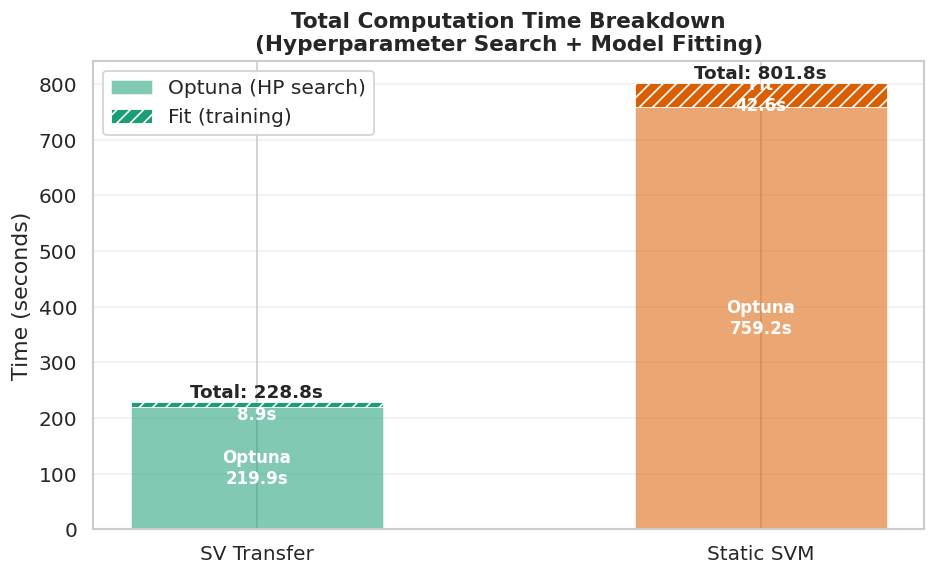

In [20]:
# ─── TIME BREAKDOWN: Optuna vs Fit ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

methods_cmp = ['SV Transfer', 'Static SVM']
optuna_times = [svt_optuna_time, st_optuna_time]
fit_times    = [svt_fit_time, st_fit_time]
total_times  = [svt_total_time, st_total_time]

x = np.arange(2)
w = 0.5

bars_opt = ax.bar(x, optuna_times, w, color=[C_SV, C_STATIC], alpha=0.55,
                  label='Optuna (HP search)', edgecolor='white', linewidth=0.5)
bars_fit = ax.bar(x, fit_times, w, bottom=optuna_times,
                  color=[C_SV, C_STATIC], alpha=1.0,
                  label='Fit (training)', edgecolor='white', linewidth=0.5,
                  hatch='///')

# Annotate each segment
for i in range(2):
    # Optuna segment
    ax.text(x[i], optuna_times[i] / 2, f'Optuna\n{optuna_times[i]:.1f}s',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    # Fit segment
    ax.text(x[i], optuna_times[i] + fit_times[i] / 2, f'Fit\n{fit_times[i]:.1f}s',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    # Total on top
    ax.text(x[i], total_times[i] + 0.5, f'Total: {total_times[i]:.1f}s',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Speedup annotation
speedup = st_total_time / svt_total_time
mid_y = max(total_times) / 2

ax.set_xticks(x)
ax.set_xticklabels(methods_cmp, fontsize=12)
ax.set_ylabel('Time (seconds)')
ax.set_title('Total Computation Time Breakdown\n(Hyperparameter Search + Model Fitting)',
             fontweight='bold', fontsize=13)
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('time_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

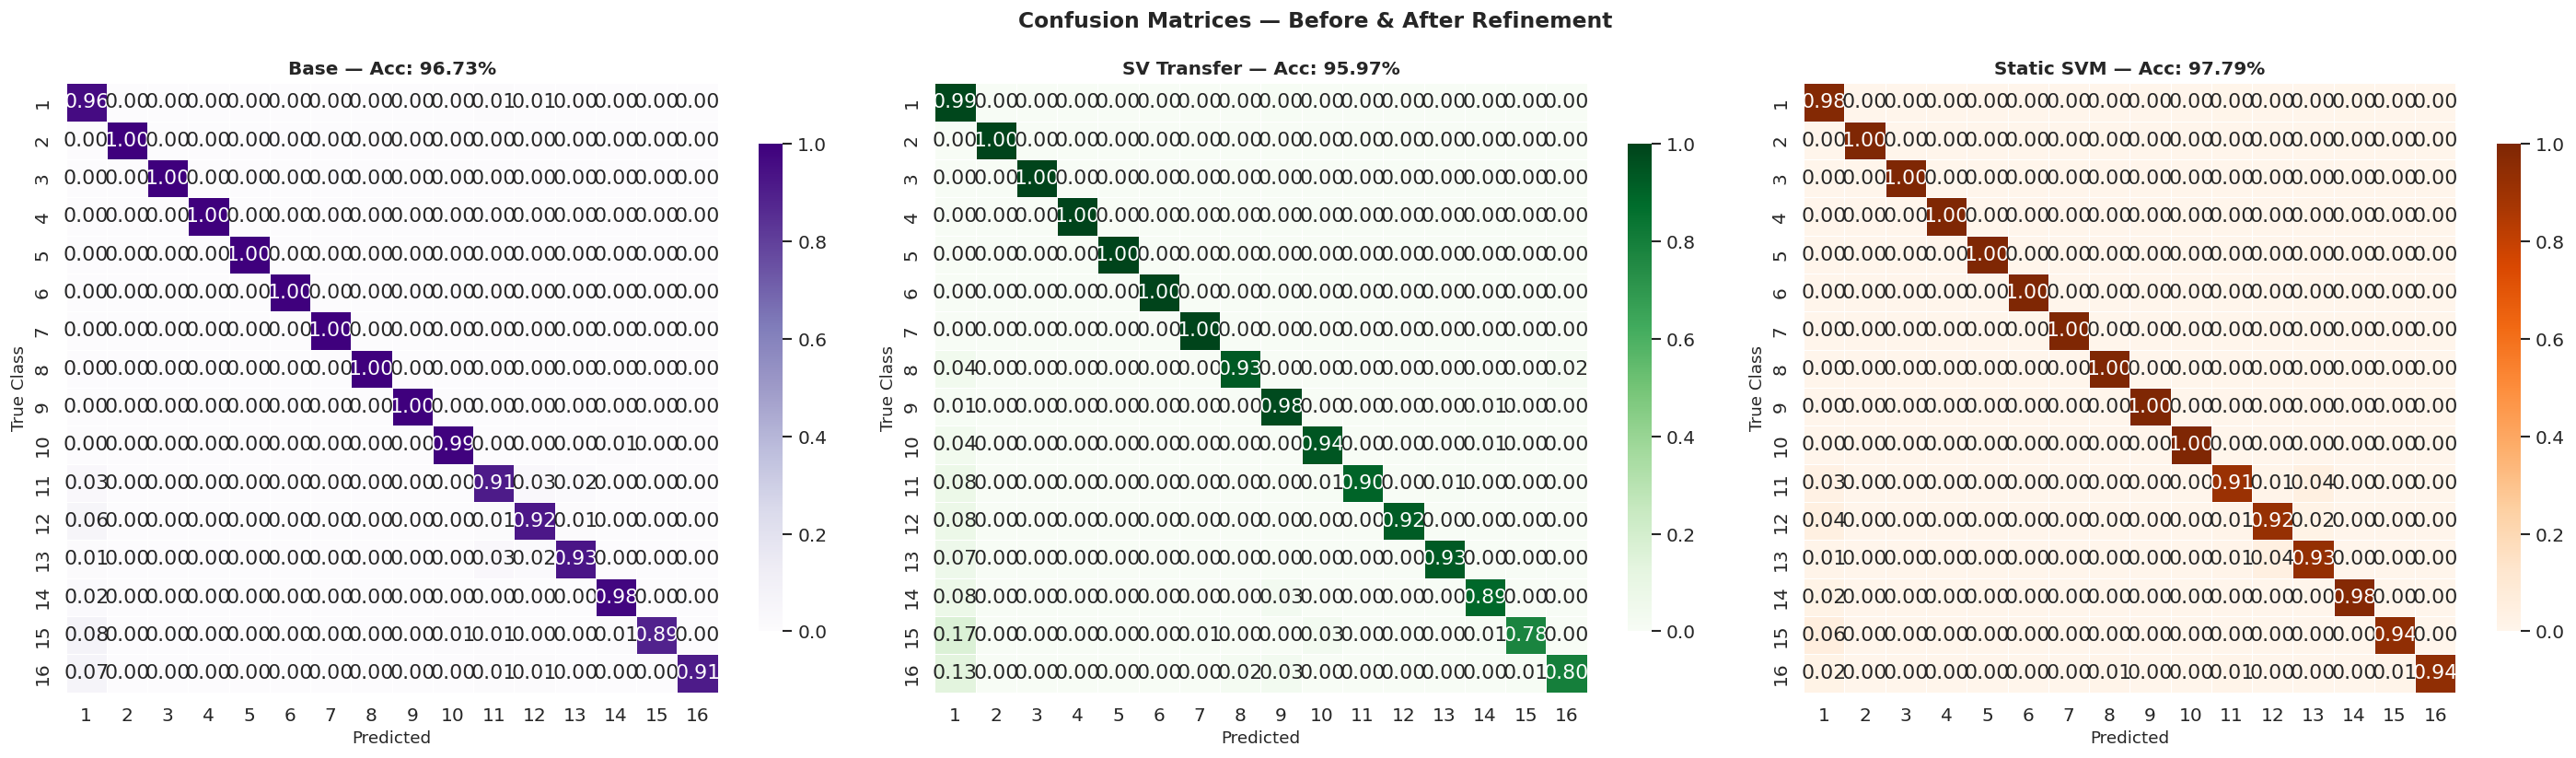

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

all_labels = np.array(sorted(np.unique(np.concatenate([y_train, y_new]))))

configs = [
    (axes[0], base_expert, f'Base — Acc: {acc_base:.2%}', 'Purples'),
    (axes[1], expert_svt,  f'SV Transfer — Acc: {acc_svt:.2%}', 'Greens'),
    (axes[2], expert_st,   f'Static SVM — Acc: {acc_st:.2%}', 'Oranges'),
]

for ax, expert, title, cmap in configs:
    y_pred = expert.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred, labels=all_labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=all_labels.astype(int),
                yticklabels=all_labels.astype(int),
                ax=ax, vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True Class', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrices — Before & After Refinement',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('refinement_confusion.png', dpi=150, bbox_inches='tight')
plt.show()